# Test en Machine Learning
## Prétraitement de données

### Etape 1 : Faites les importations des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### Etape 2 : Importer les données du fichier "dataset_ProjetML_2026.csv"

In [2]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [3]:
# Colle ça dans une cellule et montre moi le résultat
print(df.groupby('Categorie')['Prix_Revente'].agg(['min', 'max', 'mean', 'std']))

            min          max        mean          std
Categorie                                            
Métal     -50.0    29.091949   17.763935     5.320600
Papier    -50.0  9999.000000   46.074977   671.943199
Plastique -50.0  9999.000000   37.072251   583.869378
Verre     -50.0  9999.000000  130.857348  1113.439624


### Etape 3 : Afficher un échontillon du dataframe

In [4]:
df.head(10)

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.000000,1.000000,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.000000,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.000000,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.000000,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.000000,1.000000,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...
5,32.954775,43.962633,0.000000,0.352356,4.0,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...
6,187.760007,400.170299,0.000000,0.012702,8.0,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...
7,132.167170,252.346840,0.000000,0.011275,9.0,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...
8,16.712285,71.655161,0.000000,1.000000,1.0,0.835614,Papier,Usine_A,Feuilles et cartons collectés provenant de l'U...
9,60.078655,121.096923,0.953797,1.000000,7.0,18.023597,Métal,Centre_Tri,Métal de récupération au centre de tri municip...


### Etape 4 : Afficher toutes les variables du dataset et leurs types respectifs

In [5]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### Etape 5 : Afficher la description du dataset

In [6]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Etape 6 : Afficher les informations du dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### Etape 7 : Afficher le nombre de lignes et de colonnes du dataframe

In [8]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


### Etape 8 : Afficher les valeurs de chaque fearture

In [9]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [10]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### Etape 9 : Traiter les dedoublants

- Sélection des lignes dupliquées et calcul de leur nombre

In [11]:
duplicates = df[df.duplicated()]
len(duplicates)


776

- Afficher les premières lignes dupliquées

In [12]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


- Nombre de lignes dupliquées en ignorant la dernière colonne

In [13]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

- Nombre de cas où les mêmes variables (features) ont plusieurs catégories différentes (conflits)

In [14]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)
# Détection des conflits : mêmes features mais catégories différentes
# Regroupe les données par les variables explicatives (sans la colonne Categorie)
# puis compte combien de catégories différentes existent pour chaque groupe
# On garde uniquement les cas où il y a plus d'une catégorie (conflit)
# len(conflicts) donne le nombre de ces conflits

0

- Supprimer les lignes dupliquées puis réinitialiser l’index

In [15]:
df = df.drop_duplicates().reset_index(drop=True)

- Vérifier la suppréssion

In [16]:
duplicates = df[df.duplicated()]
len(duplicates)



0

In [17]:
df.shape

(9724, 9)

In [18]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


- Afficher le nombre de colonne 

In [19]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### Etape 10 : Traitement des valeurs Null (manquantes)

- Les colonnes qui  contiennent des valeurs nulls & le nombre de valeurs nulls

In [20]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


- Sélection des colonnes numériques (int et float) du dataset

In [21]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente'],
      dtype='object')


- Selection des colonne catégories

In [22]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Categorie', 'Source', 'Rapport_Collecte'], dtype='object')


- Utilisation de la méthode MAR pour voir le pourcentage de Poids manquant par catégorie

In [23]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

print("Pourcentage de Poids manquant par catégorie :")
display(df.groupby("Categorie")["Poids_missing"].mean() * 100)

print("Pourcentage de Poids manquant par source :")
display(df.groupby("Source")["Poids_missing"].mean() * 100)

Pourcentage de Poids manquant par catégorie :


Categorie
Métal        11.095700
Papier        9.268061
Plastique    10.733802
Verre         8.892617
Name: Poids_missing, dtype: float64

Pourcentage de Poids manquant par source :


Source
Centre_Tri             9.377818
Collecte_Citoyenne    10.419210
Usine_A               10.185968
Usine_B               10.381750
Name: Poids_missing, dtype: float64

- utilisation de la méthode MCAR pour détecter si les NaN sont indépendants

In [24]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

df.groupby("Categorie")["Poids_missing"].mean()

Categorie
Métal        0.110957
Papier       0.092681
Plastique    0.107338
Verre        0.088926
Name: Poids_missing, dtype: float64

=>L’analyse des valeurs manquantes de la variable Poids a été réalisée en étudiant leur distribution selon la catégorie et la source. 
Les résultats montrent que le pourcentage de valeurs manquantes reste relativement stable entre les différentes catégories (entre 8.89% et 11.09%) et les différentes sources (entre 9.37% et 10.41%). 
Cela indique que les valeurs manquantes ne dépendent pas des variables observées. 
Par conséquent, ces données peuvent être considérées comme MCAR (Missing Completely At Random). 
Dans ce cas, une imputation simple comme la médiane est appropriée, tout en comparant avec des méthodes plus avancées comme KNNImputer.

=> Les valeurs manquantes de la variable Poids ne semblent pas totalement aléatoires.
Elles varient selon la catégorie ou la source, donc elles peuvent être considérées comme MAR.
Pour cette raison, plusieurs stratégies d’imputation sont comparées : médiane, KNNImputer et IterativeImputer.

-  Remplacer les valeurs manquantes par la valeur la plus fréquente (mode) pour chaque colonne

In [25]:
df = df.dropna(subset=["Categorie"])

In [26]:
df["Source"] = df["Source"].fillna(df["Source"].mode()[0])
print(df["Source"])

0       Collecte_Citoyenne
1                  Usine_A
2                  Usine_B
3               Centre_Tri
4                  Usine_B
               ...        
9719               Usine_B
9720    Collecte_Citoyenne
9721    Collecte_Citoyenne
9722    Collecte_Citoyenne
9723               Usine_B
Name: Source, Length: 9213, dtype: object


=> Les valeurs manquantes de la variable cible Categorie ont été supprimées afin d’éviter d’introduire un biais dans le modèle.
Pour la variable catégorielle Source, les valeurs manquantes ont été remplacées par la modalité la plus fréquente (ou par une catégorie "Inconnu").

- Vérifier que les Nan pour les variables catégorique sont traités

In [27]:
print(df.isna().sum())

Poids               922
Volume              510
Conductivite        914
Opacite             946
Rigidite            526
Prix_Revente        511
Categorie             0
Source                0
Rapport_Collecte      0
Poids_missing         0
dtype: int64


- Traiter les Nan des variables numérique

In [28]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.mean()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix_Revente"] = df.groupby("Categorie")["Prix_Revente"].transform(lambda x: x.fillna(x.median()))

In [29]:
df["Rigidite"] = df.groupby("Categorie")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Categorie")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Categorie")["Opacite"].transform(lambda x: x.fillna(x.median()))

- Vérifier que les Nan sont disparus 

In [30]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
Poids_missing       0
dtype: int64


- Voir un échantillon du dataset aprés le traitement des Nan

In [31]:
df.shape

(9213, 10)

### Etape 11 :  La dataset est Equilibre ou Non

In [32]:
df["Categorie"].value_counts()

Categorie
Plastique    2562
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [33]:
#Le dataset présente un léger déséquilibre entre les classes. 
#La classe "Plastique" est dominante par rapport aux autres classes. 
#Cependant, ce déséquilibre reste modéré et peut être acceptable selon le modèle utilisé.

- Equilibrer la dataset avec class_weight

In [34]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight="balanced")

### Etape 12 : La corrélation entre les variables

<Axes: >

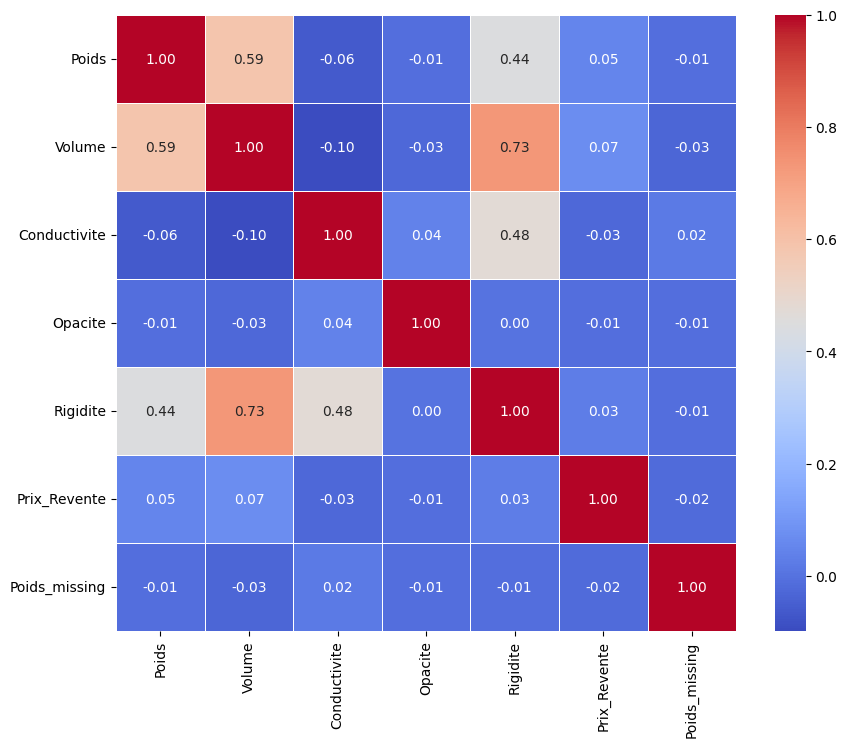

In [35]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

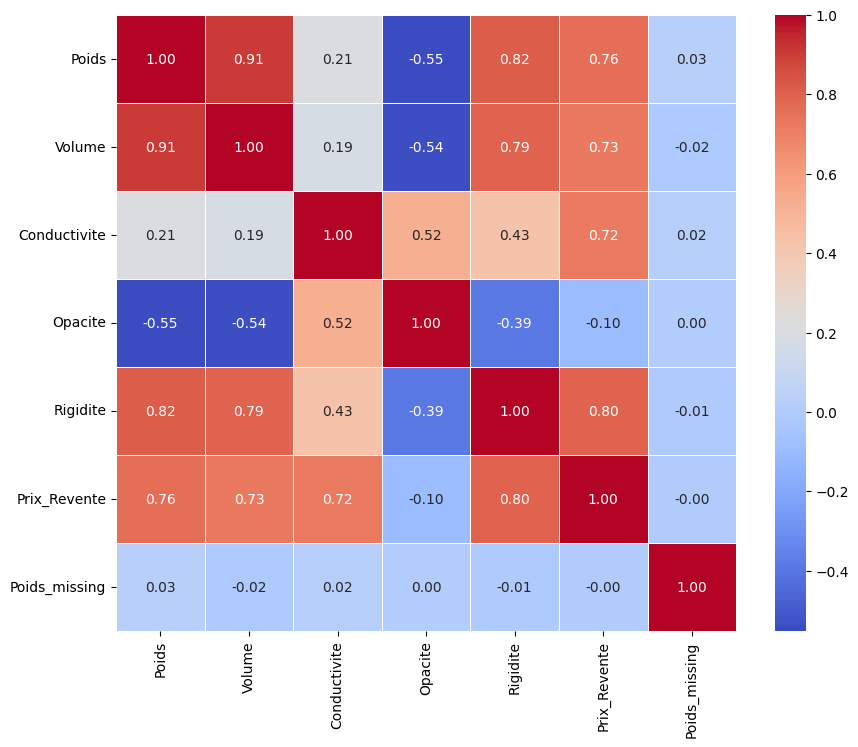

In [36]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

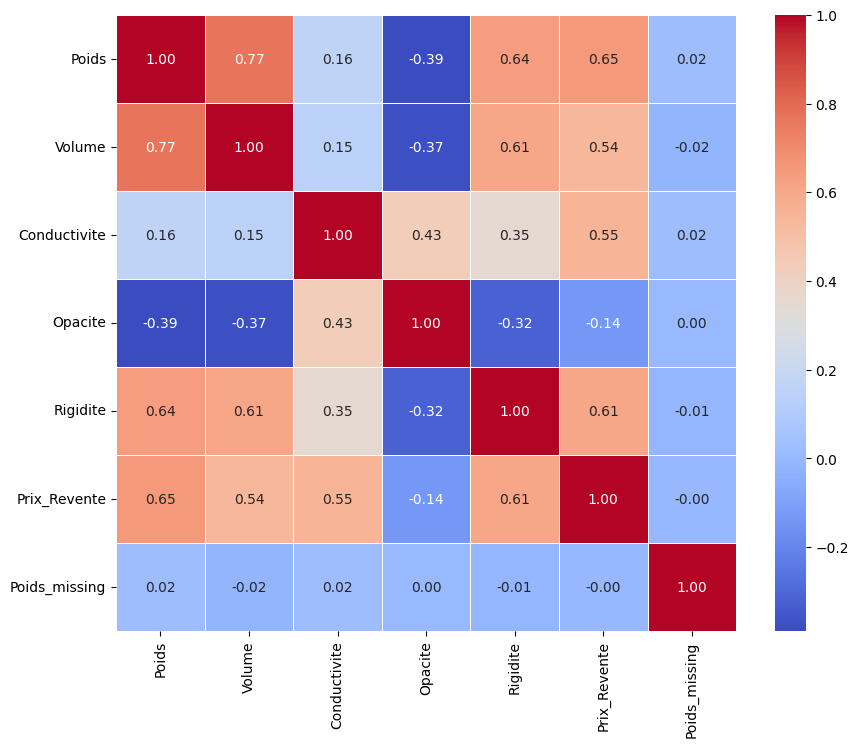

In [37]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

=> Dans ce travail, nous avons utilisé plusieurs méthodes de corrélation pour analyser les relations entre les variables. 
La corrélation de Pearson permet de mesurer les relations linéaires entre les variables numériques. 
La corrélation de Spearman est utilisée pour détecter des relations même non linéaires et elle est plus robuste face aux valeurs aberrantes. 
Enfin, la corrélation de Kendall, plus précise mais plus lente, peut être utilisée pour confirmer les résultats. 
Ces méthodes permettent de mieux comprendre les liens entre les variables.

### Etape 13 : Traiter les outliers

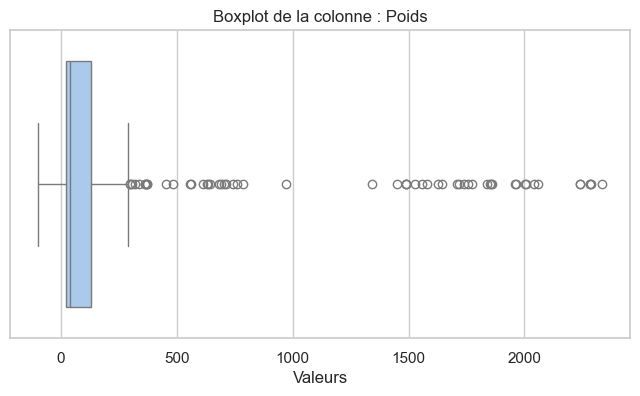

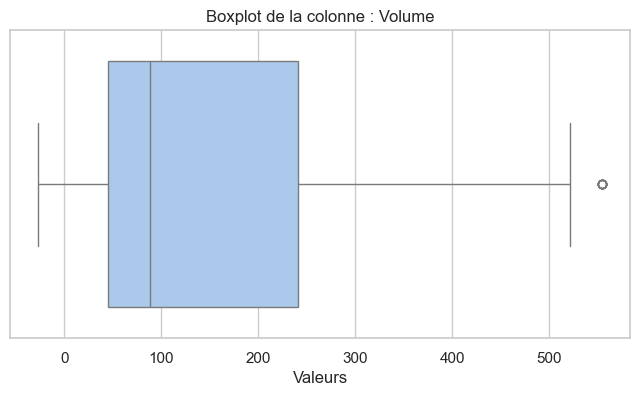

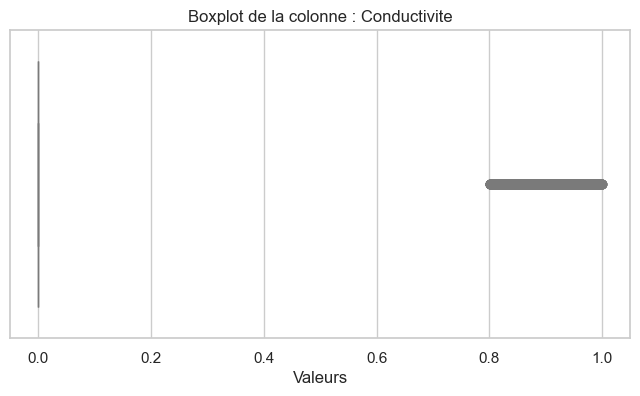

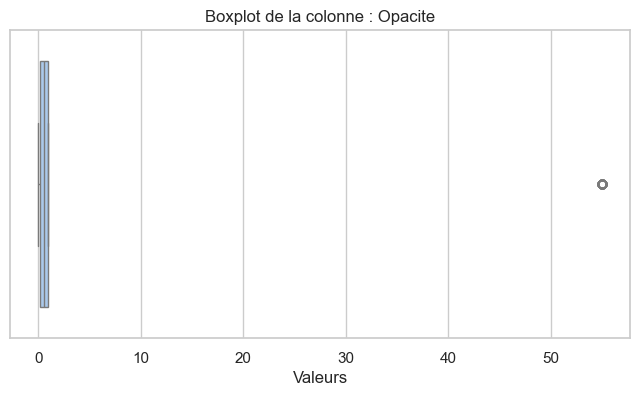

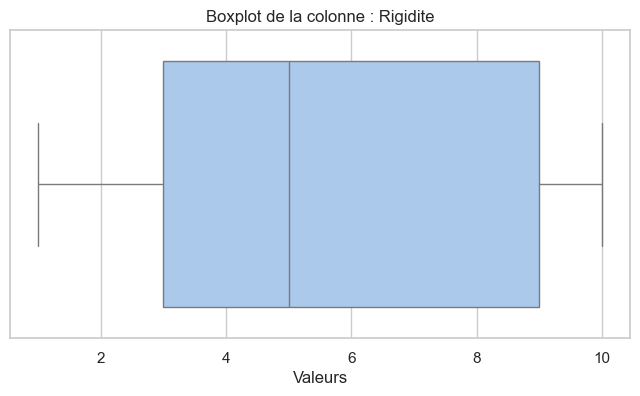

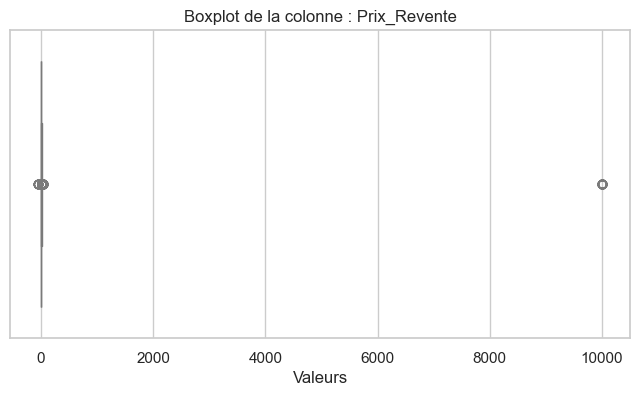

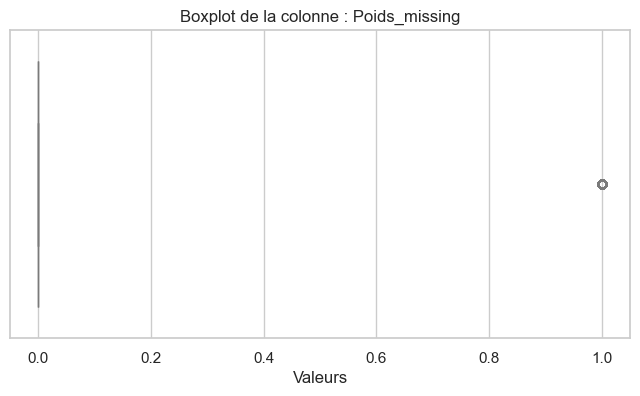

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

- Traiter les valeurs outilers par la méthode de Quartile

In [39]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


In [40]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR

df = df[(df['Poids'] >= inf) & (df['Poids'] <= sup)]


In [41]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


In [42]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


In [43]:
Q1 = df['Opacite'].quantile(0.25)
Q3 = df['Opacite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Opacite'] >= inf) & (df['Opacite'] <= sup)]


- vérifier la modification des VA

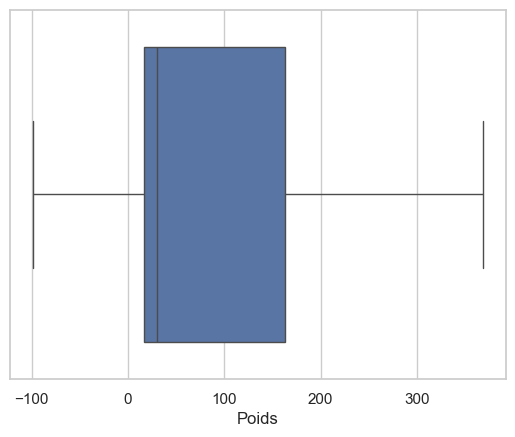

In [44]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

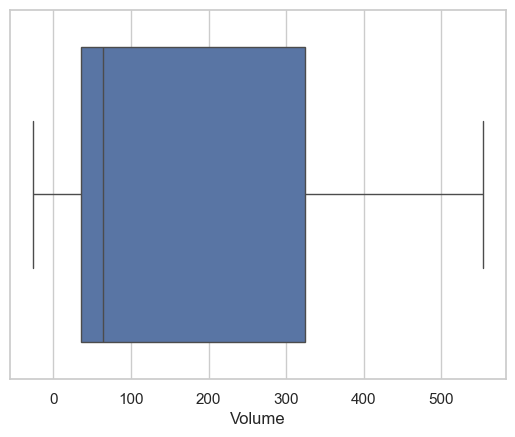

In [45]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

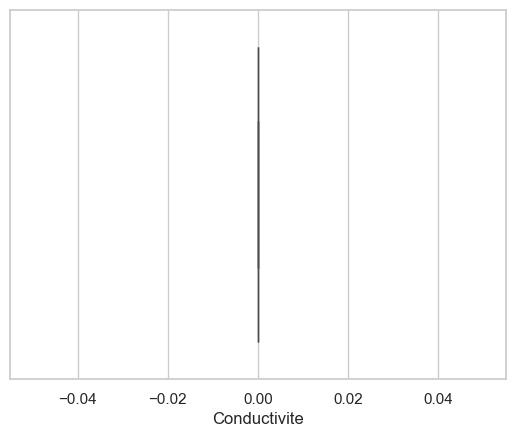

In [46]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

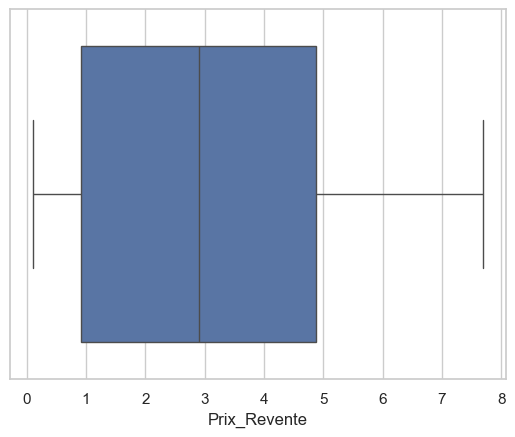

In [47]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

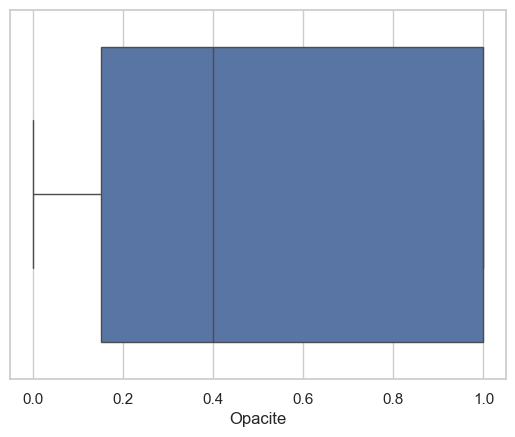

In [48]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Opacite'] ,orient='h')

- relation entre rigidité et volume

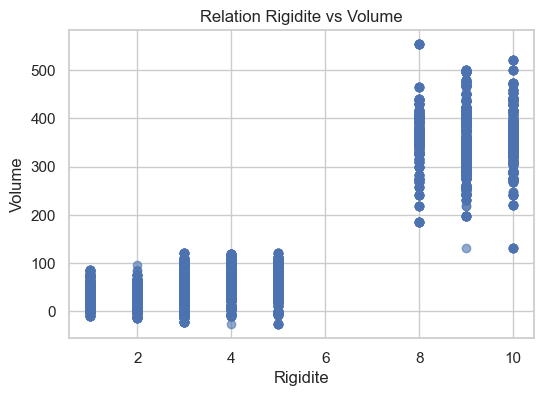

In [49]:
plt.figure(figsize=(6,4))
plt.scatter(df['Rigidite'], df['Volume'], alpha=0.6)
plt.xlabel('Rigidite')
plt.ylabel('Volume')
plt.title('Relation Rigidite vs Volume')
plt.show()

# Plus la rigidité augmente
# plus le volume est élevé 


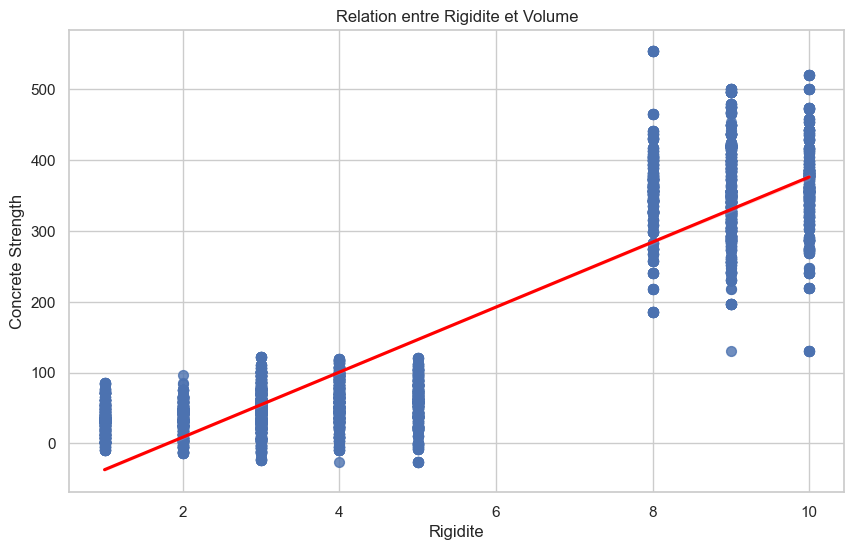

In [50]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Rigidite', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Rigidite et Volume')
plt.xlabel('Rigidite')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

-  relation entre Poids et volume

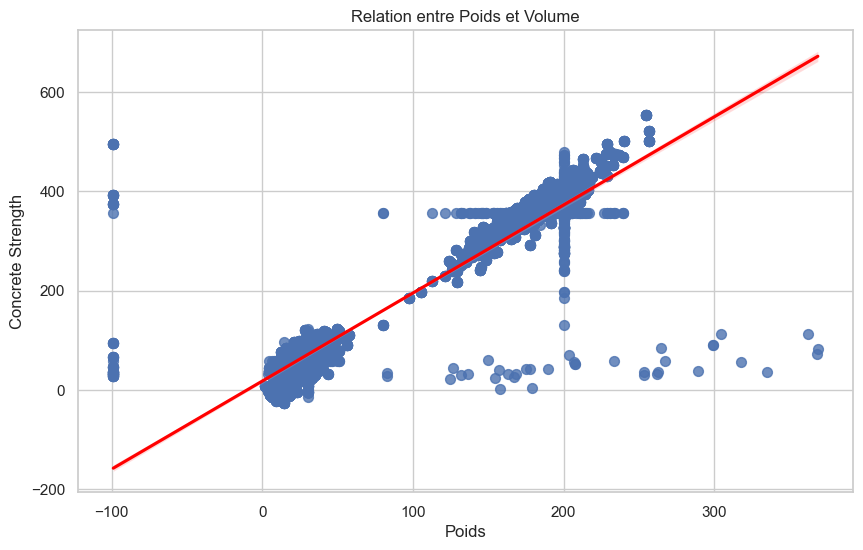

In [51]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Poids et Volume')
plt.xlabel('Poids')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

- Les Relations entre les variables avec pairplot

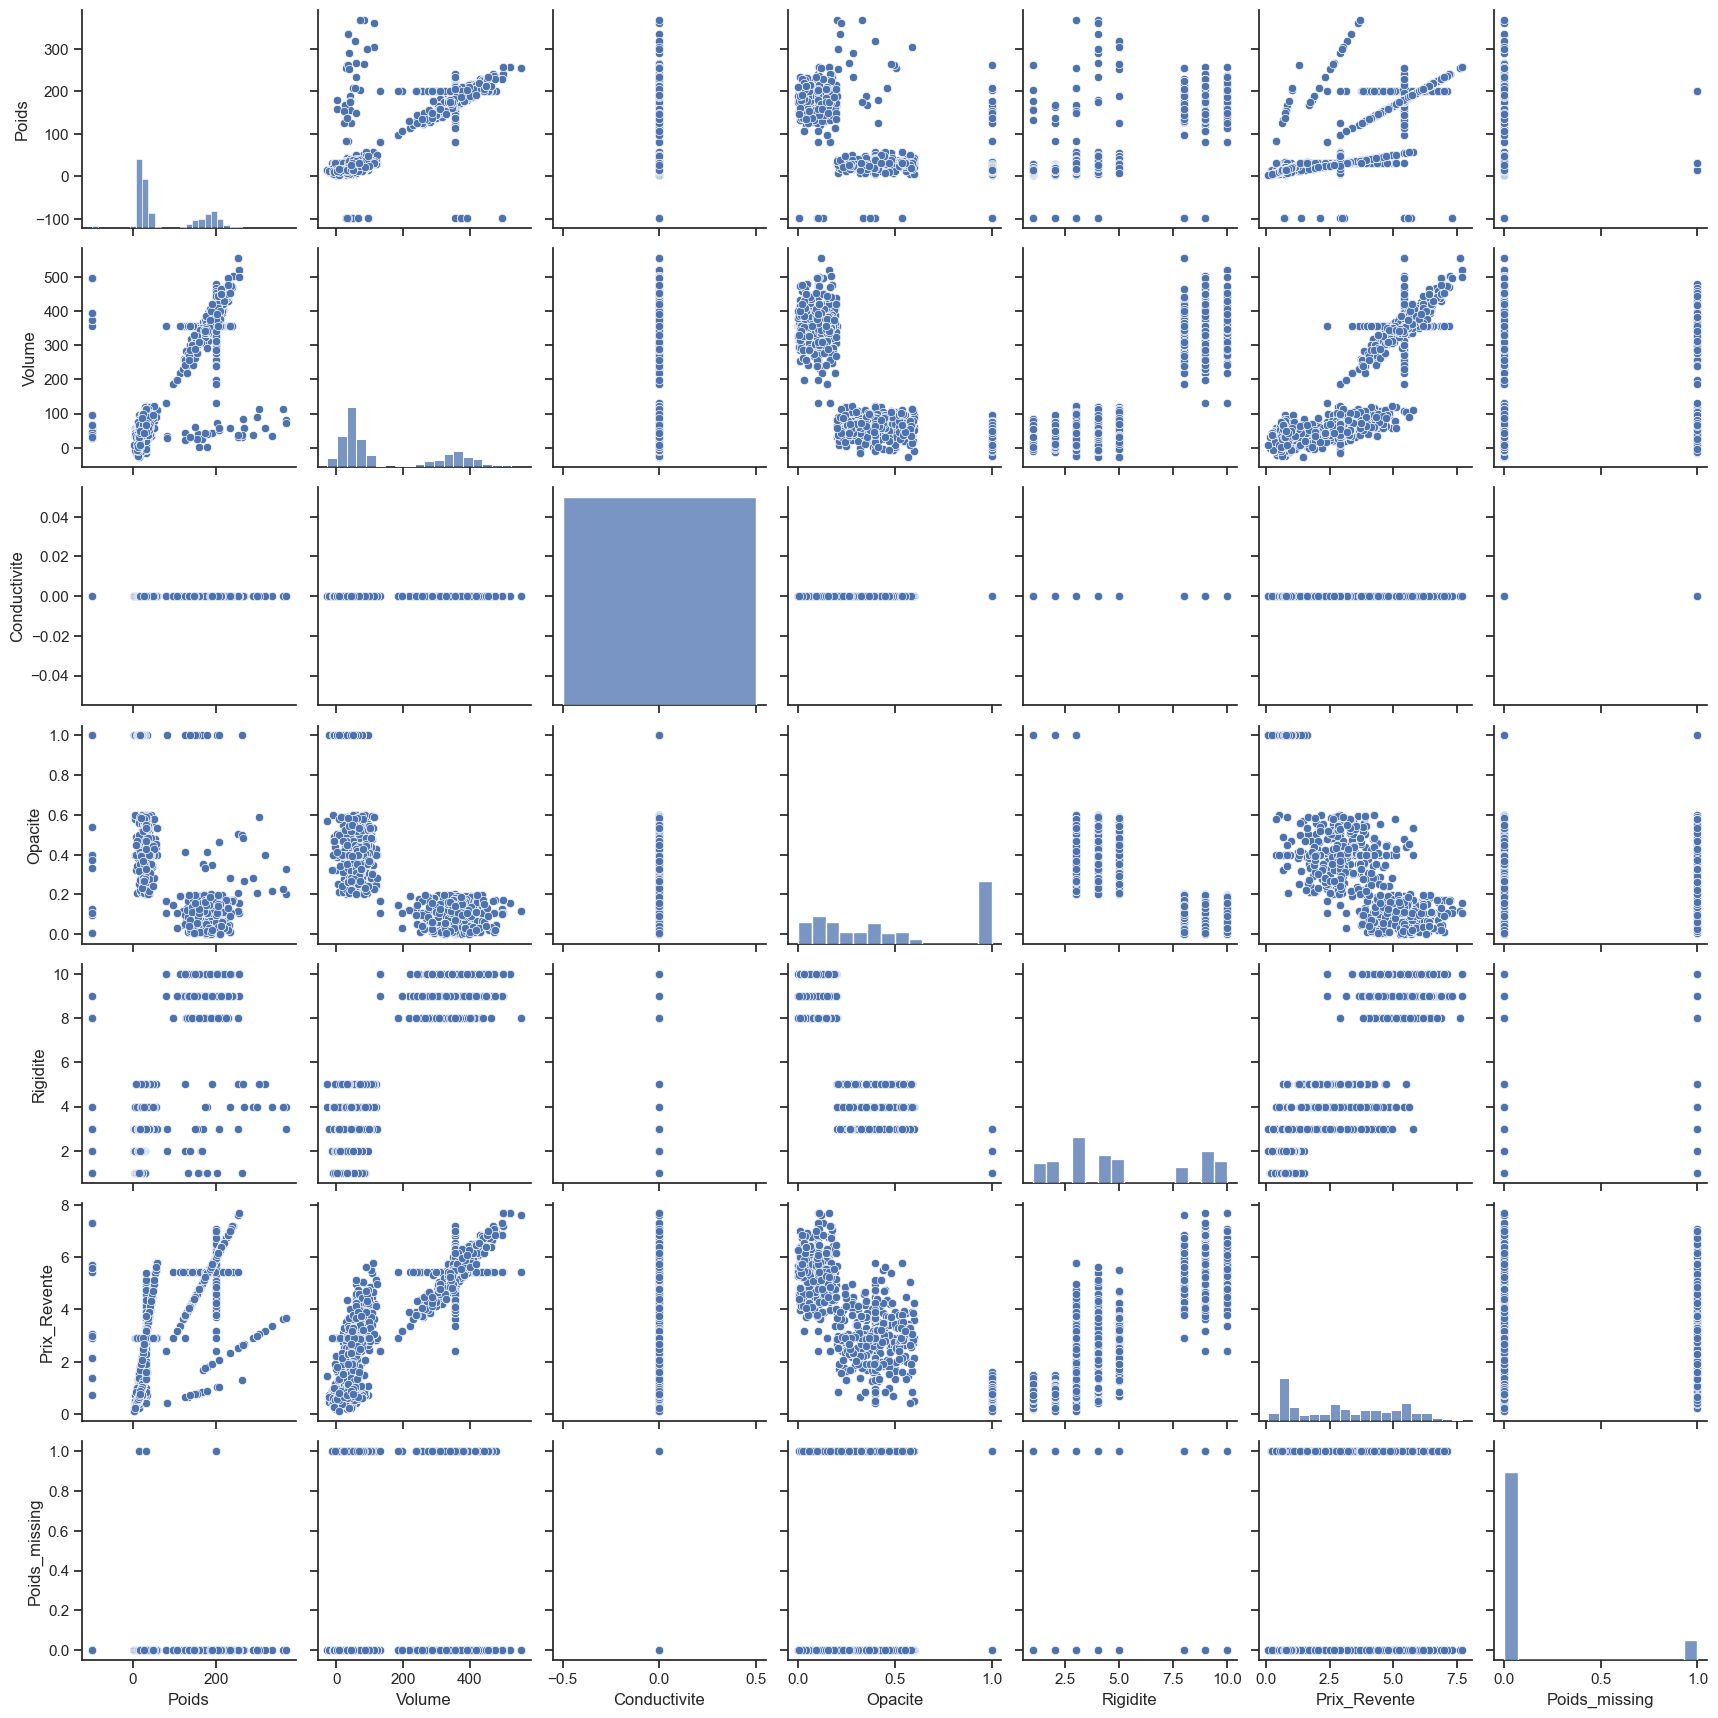

In [52]:
sns.set(style='ticks')
sns.pairplot(df)

### Etape 14 : Séparation des variables

- Pour Classification

In [53]:
# =========================================================
# CLASSIFICATION : séparation des variables
# Objectif : prédire la colonne Categorie
# =========================================================

# Cible
Y_class = df["Categorie"]

# Variables explicatives
# On supprime :
# - Categorie : car c'est la cible
# - Rapport_Collecte : texte utilisé dans la partie NLP
# - Poids_missing : colonne technique créée pour l'analyse des valeurs manquantes
# - Prix_Revente : cible de la régression, à ne pas utiliser ici pour éviter la fuite de données
colonnes_a_supprimer = ["Categorie", "Rapport_Collecte", "Poids_missing", "Prix_Revente"]
colonnes_a_supprimer = [col for col in colonnes_a_supprimer if col in df.columns]

X_class = df.drop(columns=colonnes_a_supprimer)

print("Shape X_class :", X_class.shape)
print("Shape Y_class :", Y_class.shape)

print("\nColonnes utilisées pour la classification :")
print(X_class.columns.tolist())

print("\nDistribution de la cible :")
print(Y_class.value_counts())


Shape X_class : (6904, 6)
Shape Y_class : (6904,)

Colonnes utilisées pour la classification :
['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source']

Distribution de la cible :
Categorie
Plastique    2530
Verre        2288
Papier       2086
Name: count, dtype: int64


- Pour Regression

In [54]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte","Poids_missing"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 6904, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000       1.0     Papier   
1      47.277476   64.702925           0.0  0.400606       3.0  Plastique   
2     200.203552  317.415183           0.0  0.105535       9.0      Verre   
3      14.664058   21.474391           0.0  1.000000       1.0     Papier   
4      14.664058   59.462176           0.0  1.000000       2.0     Papier   
...          ...         ...           ...       ...       ...        ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      Verre   
9720  149.052713  287.519460           0.0  0.157940      10.0      Verre   
9721   15.572667   50.148243           0.0  1.00

In [55]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [56]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite      Source
7976   26.008881   58.048818           0.0  0.357830       5.0     Usine_B
5376  159.031487  343.107232           0.0  0.189814       9.0  Centre_Tri
5044   35.059911   30.171595           0.0  0.400606       4.0  Centre_Tri
7388   16.026334   26.806749           0.0  1.000000       3.0  Centre_Tri
861   182.421199  352.218602           0.0  0.031207       9.0     Usine_B

Echantillon de Y :
5500    Plastique
2614        Verre
3902    Plastique
9185        Verre
2057    Plastique
Name: Categorie, dtype: object


In [57]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
2393  191.402361  360.432336           0.0  0.072620      10.0      Verre   
79     38.678490   58.626700           0.0  0.437185       3.0  Plastique   
4734   42.509545   89.543666           0.0  0.485138       5.0  Plastique   
895    19.214629   20.530511           0.0  0.311957       4.0  Plastique   
4802   18.904077   25.316136           0.0  1.000000       3.0     Papier   

                  Source  
2393             Usine_B  
79               Usine_A  
4734             Usine_A  
895           Centre_Tri  
4802  Collecte_Citoyenne  

Echantillon de Y :
5095    2.177379
3159    3.505991
1286    3.643993
7500    0.804366
8845    3.587930
Name: Prix_Revente, dtype: float64


### Etape 15 : categorisation

In [58]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [59]:
print(Y_class)

[0 1 2 ... 0 1 2]


In [60]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [61]:
print(X_class)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 0.00000000e+00
  4.00606185e-01 3.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.05535493e-01 9.00000000e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.66208204e-01 4.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  5.07727113e-03 9.00000000e+00]]


In [62]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)


X_regg = ct.fit_transform(X_regg)

In [63]:
print(X_regg)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 0.00000000e+00
  4.00606185e-01 3.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.05535493e-01 9.00000000e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.66208204e-01 4.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  5.07727113e-03 9.00000000e+00]]


### Etape 16 : Transformer X et Y en tableau numpy

- Classification

In [64]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)


print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (6904, 9)
Shape de Y : (6904,)


- Regression

In [65]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (6904, 12)
Shape de Y : (6904,)


- Vérifier cette transformation

In [66]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.00606185e-01,
        3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.46640579e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        2.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        3.29547752e+01, 4.39626331e+01, 0.00000000e+00, 3.52356343e-01,
        4.0

In [67]:
Y_class

array([0, 1, 2, ..., 0, 1, 2])

In [68]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.67087799e+01,
        7.09409765e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 4.72774763e+01,
        6.47029253e+01, 0.00000000e+00, 4.00606185e-01, 3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 2.00203552e+02,
        3.17415183e+02, 0.00000000e+00, 1.05535493e-01, 9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46640579e+01,
        2.14743907e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46

In [69]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### Etape 17 : Split

- Classification

In [77]:
from sklearn.model_selection import train_test_split

# Séparation train/test avec stratify pour garder la même distribution des catégories
x_train, x_test, y_train, y_test = train_test_split(
    X_class,
    Y_class,
    test_size=0.2,
    random_state=0,
    stratify=Y_class
)

print("x_train :", x_train.shape)
print("x_test  :", x_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nDistribution y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribution y_test :")
print(y_test.value_counts(normalize=True) * 100)


x_train : (5523, 9)
x_test  : (1381, 9)
y_train : (5523,)
y_test  : (1381,)

Distribution y_train :


AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

- Regression

In [71]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (5523, 12)
x_test: (1381, 12)
y_train: (5523,)
y_test: (1381,)
y_train: 3.0844865453997854
y_test: 3.0433586046816603


### Etape 18 : Standarisation

- Classification

In [74]:
# =========================================================
# Prétraitement pour les modèles de classification
# =========================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Colonnes numériques et catégorielles
num_cols_class = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_class = x_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Colonnes numériques :", num_cols_class)
print("Colonnes catégorielles :", cat_cols_class)

# Pipeline pour les colonnes numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les colonnes catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Préprocesseur général
preprocessor_class = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_class),
        ("cat", categorical_transformer, cat_cols_class)
    ]
)


AttributeError: 'numpy.ndarray' object has no attribute 'select_dtypes'

In [75]:
# Vérification
print("Prétraitement prêt pour la classification.")


Prétraitement prêt pour la classification.


- Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [ ]:
print(x_train_reg[:5])

[[-0.53918655  1.50600376 -0.56933548 -0.53722816 -0.65270693  1.3107295
  -0.70710678 -0.5190241  -0.6496629   0.         -0.19559738 -0.36118184]
 [-0.53918655  1.50600376 -0.56933548 -0.53722816  1.53208118 -0.76293393
  -0.70710678 -0.71555205 -0.98474602  0.          1.4090642  -1.35214425]
 [-0.53918655 -0.66400896  1.75643365 -0.53722816 -0.65270693 -0.76293393
   1.41421356  1.04851739  1.30899764  0.         -1.01595489  0.96010137]
 [-0.53918655 -0.66400896 -0.56933548  1.86140653 -0.65270693  1.3107295
  -0.70710678 -0.52413795 -0.65268106  0.          0.26261081 -0.36118184]
 [-0.53918655  1.50600376 -0.56933548 -0.53722816  1.53208118 -0.76293393
  -0.70710678 -0.67572841 -0.74691263  0.          1.4090642  -1.02182345]]


# Classification

## * Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report

# =========================================================
# Modèle 1 : KNN
# =========================================================
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor_class),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

# Entraînement
knn_model.fit(x_train, y_train)

# Prédiction
y_pred_knn = knn_model.predict(x_test)

# Évaluation
knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_rec  = recall_score(y_test, y_pred_knn, average="macro", zero_division=0)
knn_prec = precision_score(y_test, y_pred_knn, average="macro", zero_division=0)
knn_f1   = f1_score(y_test, y_pred_knn, average="macro", zero_division=0)

print("Confusion Matrix KNN :\n", confusion_matrix(y_test, y_pred_knn))
print(f"\nAccuracy  : {knn_acc:.4f}")
print(f"Recall    : {knn_rec:.4f}")
print(f"Precision : {knn_prec:.4f}")
print(f"F1-score  : {knn_f1:.4f}")

print("\nClassification Report KNN :\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))


NameError: name 'preprocessor_class' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test_eval, y_pred_knn)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - KNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [ ]:
from sklearn.model_selection import GridSearchCV

# =========================================================
# Optimisation KNN avec GridSearchCV
# =========================================================
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_class),
    ("model", KNeighborsClassifier())
])

parameters = {
    "model__n_neighbors": [1, 3, 5, 7, 9, 11, 13],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(x_train, y_train)

print("Meilleurs paramètres :", grid_knn.best_params_)
print("Meilleur score CV    :", grid_knn.best_score_)

# Prédiction avec le meilleur modèle
y_pred_knn_opt = grid_knn.predict(x_test)

# Évaluation
knn_op_acc  = accuracy_score(y_test, y_pred_knn_opt)
knn_op_rec  = recall_score(y_test, y_pred_knn_opt, average="macro", zero_division=0)
knn_op_prec = precision_score(y_test, y_pred_knn_opt, average="macro", zero_division=0)
knn_op_f1   = f1_score(y_test, y_pred_knn_opt, average="macro", zero_division=0)

print("\nConfusion Matrix KNN optimisé :\n", confusion_matrix(y_test, y_pred_knn_opt))
print(f"Accuracy  : {knn_op_acc:.4f}")
print(f"Recall    : {knn_op_rec:.4f}")
print(f"Precision : {knn_op_prec:.4f}")
print(f"F1-score  : {knn_op_f1:.4f}")

print("\nClassification Report KNN optimisé :\n")
print(classification_report(y_test, y_pred_knn_opt, zero_division=0))


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# =========================================================
# Modèle 2 : Decision Tree
# =========================================================
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor_class),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=0))
])

dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

# Évaluation
dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_rec  = recall_score(y_test, y_pred_dt, average="macro", zero_division=0)
dt_prec = precision_score(y_test, y_pred_dt, average="macro", zero_division=0)
dt_f1   = f1_score(y_test, y_pred_dt, average="macro", zero_division=0)

print("Confusion Matrix Decision Tree :\n", confusion_matrix(y_test, y_pred_dt))
print(f"\nAccuracy  : {dt_acc:.4f}")
print(f"Recall    : {dt_rec:.4f}")
print(f"Precision : {dt_prec:.4f}")
print(f"F1-score  : {dt_f1:.4f}")

print("\nClassification Report Decision Tree :\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))


## Importance des features

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# Modèle 3 : Random Forest
# =========================================================
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_class),
    ("model", RandomForestClassifier(n_estimators=500, random_state=0))
])

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

# Évaluation
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_prec = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, average="macro", zero_division=0)

print("Confusion Matrix Random Forest :\n", confusion_matrix(y_test, y_pred_rf))
print(f"\nAccuracy  : {rf_acc:.4f}")
print(f"Recall    : {rf_rec:.4f}")
print(f"Precision : {rf_prec:.4f}")
print(f"F1-score  : {rf_f1:.4f}")

print("\nClassification Report Random Forest :\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))


les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')
svm_f1    = f1_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(f'Score-F1 : {svm_rec:.4f}')
print(classification_report(y_test, y_predictSVM_l))

[[436   0   0]
 [  0 498   0]
 [  0   0 447]]
Accuracy linear SVM 1.000
Precision linear SVM 1.000
Recall linear SVM 1.000
Score-F1 : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       436
           1       1.00      1.00      1.00       498
           2       1.00      1.00      1.00       447

    accuracy                           1.00      1381
   macro avg       1.00      1.00      1.00      1381
weighted avg       1.00      1.00      1.00      1381



# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [ ]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes
LR_f1     = f1_score(y_test,  y_predictLR, average='macro')  # si Logistic Regression existefrom sklearn.metrics import f1_score

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))
print('F1-Score Logistic Regression {0:.3f}'.format(LR_f1))
print(classification_report(y_test, y_predictLR))

[[436   0   0]
 [  0 498   0]
 [  0   0 447]]
Accuracy Logistic Regression 1.000
Precision Logistic Regression 1.000
Recall Logistic Regression 1.000
F1-Score Logistic Regression 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       436
           1       1.00      1.00      1.00       498
           2       1.00      1.00      1.00       447

    accuracy                           1.00      1381
   macro avg       1.00      1.00      1.00      1381
weighted avg       1.00      1.00      1.00      1381



# Sommary

In [ ]:
print("| Algorithm         | Accuracy   | Recall     | Precision  | F1-score ")
print("| ----------------- | ---------- | ---------- | ---------- |----------")
print("| Optimized kNN     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(knn_op_acc, knn_op_rec, knn_op_prec , knn_op_f1))
print("| Decision Tree     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(accur_dt, rec_dt, pres_dt,dt_f1))
print("| Random Forest     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(rf_acc, rf_rec, rf_prec,rf_f1,))
print("| Linear SVM        | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(svm_acc, svm_rec, svm_prec,svm_rec))
print("| Logistic Reg      | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f}".format(LR_acc, LR_rec, LR_prec,LR_f1))

| Algorithm         | Accuracy   | Recall     | Precision  | F1-score 
| ----------------- | ---------- | ---------- | ---------- |----------
| Optimized kNN     | 0.99928    | 0.99933    | 0.99924    |0.99928 
| Decision Tree     | 1.00000    | 1.00000    | 1.00000    |1.00000 
| Random Forest     | 1.00000    | 1.00000    | 1.00000    |1.00000 
| Linear SVM        | 1.00000    | 1.00000    | 1.00000    |1.00000 
| Logistic Reg      | 1.00000    | 1.00000    | 1.00000    |1.00000


# Regression

# Régression linéaire

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.9279381767665705
MAE   : 0.38388936424529496
MSE   : 0.2937926687246192
RMSE  : 0.542026446517713
MAPE  : 0.2305999747081267
MEDAE : 0.2708539165542785
          0         1         2         3         4         5         6  \
0  1.854646 -0.664009 -0.569335 -0.537228 -0.652707 -0.762934  1.414214   
1 -0.539187  1.506004 -0.569335 -0.537228 -0.652707  1.310729 -0.707107   
2 -0.539187  1.506004 -0.569335 -0.537228 -0.652707 -0.762934  1.414214   
3 -0.539187 -0.664009 -0.569335  1.861407 -0.652707 -0.762934  1.414214   
4 -0.539187 -0.664009 -0.569335  1.861407 -0.652707  1.310729 -0.707107   

          7         8    9        10        11  prix_reel  prix_predit  
0  1.224154  1.161105  0.0 -1.037650  1.290422   5.178544     4.948386  
1 -0.662074 -0.607961  0.0 -0.550404 -0.691503   2.189224     2.848044  
2  0.633026  0.688566  0.0 -1.034856  1.290422   3.761457     3.874777  
3  1.950871  2.145485  0.0 -1.015955  1.290422   6.920673     7

# Régression Ridge/Lasso (avec régularisation)


- Ridge

In [ ]:
from sklearn.linear_model import Ridge
# création du modèle
ridge_model = Ridge(alpha=1.0)
# entraînement
ridge_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_ridge = ridge_model.predict(x_test_reg)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_reg, y_pred_ridge)
medae_ridge = median_absolute_error(y_test_reg, y_pred_ridge)
print("Ridge Regression")
print("R2 :", r2_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE :", rmse_ridge)
print("MAPE :", mape_ridge)
print("MEDAE :",medae_ridge)

Ridge Regression
R2 : 0.9280000040938678
MAE : 0.38356254512219906
MSE : 0.2935406016151328
RMSE : 0.5417938737334825
MAPE : 0.23053547486338707
MEDAE : 0.26897687246329494


- Lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
# création du modèle
lasso_model = Lasso(alpha=0.1)
# entraînement
lasso_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_lasso = lasso_model.predict(x_test_reg)

In [ ]:
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mape_lasso = mean_absolute_percentage_error(y_test_reg, y_pred_lasso)
medae_lasso = median_absolute_error(y_test_reg, y_pred_lasso)
print("Lasso Regression")
print("R2 :", r2_lasso)
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAPE :",mape_lasso)
print("MEDAE :",medae_lasso)

Lasso Regression
R2 : 0.9109275864695563
MAE : 0.44394603880342953
MSE : 0.36314404641252856
RMSE : 0.6026143430192552
MAPE : 0.2634339817466957
MEDAE : 0.3320276148512171


# ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet
# création du modèle
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
# entraînement
elastic_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_elastic = elastic_model.predict(x_test_reg)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_elastic = r2_score(y_test_reg, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test_reg, y_pred_elastic)
mse_elastic = mean_squared_error(y_test_reg, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
print("ElasticNet Regression")
print("R2 :", r2_elastic)
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)

ElasticNet Regression
R2 : 0.9097776441611154
MAE : 0.4416510558584085
MSE : 0.3678323071935777
RMSE : 0.6064918030720429


# Régression polynomiale

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(x_train_reg, y_train_reg)
y_pred_poly = poly_model.predict(x_test_reg)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
r2_poly = r2_score(y_test_reg, y_pred_poly)
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = mean_absolute_percentage_error(y_test_reg, y_pred_poly)
medae_poly = median_absolute_error(y_test_reg, y_pred_poly)
print("Polynomial Regression")
print("R2 :", r2_poly)
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("MAPE :",mape_poly)
print("MEDAE :",medae_poly)

Polynomial Regression
R2 : 0.9412252727715623
MAE : 0.339964143110618
MSE : 0.23962180238029052
RMSE : 0.48951180004193007
MAPE : 0.19297974885680386
MEDAE : 0.21918873958978136


#  DecisionTreeRegressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(x_train_reg, y_train_reg)
y_pred_tree = tree_model.predict(x_test_reg)
r2_tree = r2_score(y_test_reg, y_pred_tree)
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree)
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree)
medae_tree = median_absolute_error(y_test_reg, y_pred_tree)
print("Decision Tree Regressor")
print("R2 :", r2_tree)
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE :", rmse_tree)
print("MAPE :",mape_tree)
print("MEDAE :",medae_tree)

Decision Tree Regressor
R2 : 0.9678511414751493
MAE : 0.21364971479658143
MSE : 0.13106938623896128
RMSE : 0.3620350621679636
MAPE : 0.10958492004113826
MEDAE : 0.1149833541175882


#  RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train_reg, y_train_reg)
y_pred_rf = rf_model.predict(x_test_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf)
medae_rf = median_absolute_error(y_test_reg, y_pred_rf)
print("Random Forest")
print("R2 :", r2_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAPE :",mape_rf)
print("MEDAE :",medae_rf)

Random Forest
R2 : 0.9864607982988027
MAE : 0.09265593575237153
MSE : 0.05519868942686408
RMSE : 0.23494401338800713
MAPE : 0.042296254588084926
MEDAE : 0.01553509370025763


# GradientBoostingRegressor


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
gbr_model.fit(x_train_reg, y_train_reg)
y_pred_gbr = gbr_model.predict(x_test_reg)
r2_gbr = r2_score(y_test_reg, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mape_gbr = mean_absolute_percentage_error(y_test_reg, y_pred_gbr)
medae_gbr = median_absolute_error(y_test_reg, y_pred_gbr)
print("Gradient Boosting")
print("R2 :", r2_gbr)
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE :", rmse_gbr)
print("MAPE :",mape_gbr)
print("MEDAE :",medae_gbr)

Gradient Boosting
R2 : 0.9824797632340132
MAE : 0.1376113090184833
MSE : 0.07142918240484676
RMSE : 0.267262384941927
MAPE : 0.06538413570869203
MEDAE : 0.06205663278824858


# XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)
xgb_model.fit(x_train_reg, y_train_reg)
y_pred_xgb = xgb_model.predict(x_test_reg)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_reg, y_pred_xgb)
medae_xgb = median_absolute_error(y_test_reg, y_pred_xgb)
print("XGBoost")
print("R2 :", r2_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :",mape_xgb)
print("MEDAE :",medae_xgb)

XGBoost
R2 : 0.9881435364955743
RMSE : 0.21985960254998083
MAPE : 0.043885433366998204
MEDAE : 0.024001241016827546


# LightGBM

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    verbosity=-1
)
lgb_model.fit(x_train_reg, y_train_reg)
y_pred_lgb = lgb_model.predict(x_test_reg)
r2_lgb = r2_score(y_test_reg, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test_reg, y_pred_lgb)
mse_lgb = mean_squared_error(y_test_reg, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mape_lgb = mean_absolute_percentage_error(y_test_reg, y_pred_lgb)
medae_lgb = median_absolute_error(y_test_reg, y_pred_lgb)
print("LightGBM")
print("R2 :", r2_lgb)
print("RMSE :", rmse_lgb)
print("MAPE :",mape_lgb)
print("MEDAE :",medae_lgb)

LightGBM
R2 : 0.9872964879238706
RMSE : 0.22757772754844385
MAPE : 0.046058007132111195
MEDAE : 0.027681306807237682


# CatBoost

In [ ]:
# =========================================================
# 1. IMPORTS
# =========================================================
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
import pandas as pd
import shap

# =========================================================
# 2. TRAIN CATBOOST (BASELINE)
# =========================================================
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model.fit(x_train_reg, y_train_reg)
y_pred_cat = cat_model.predict(x_test_reg)

# Metrics AVANT SHAP
r2_cat = r2_score(y_test_reg, y_pred_cat)
mae_cat = mean_absolute_error(y_test_reg, y_pred_cat)
mse_cat = mean_squared_error(y_test_reg, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
mape_cat = mean_absolute_percentage_error(y_test_reg, y_pred_cat)
medae_cat = median_absolute_error(y_test_reg, y_pred_cat)

print("=== CatBoost AVANT SHAP ===")
print("R2 :", r2_cat)
print("RMSE :", rmse_cat)
print("MAPE :", mape_cat)
print("MEDAE :", medae_cat)



=== CatBoost AVANT SHAP ===
R2 : 0.9872240657218689
RMSE : 0.22822551126495497
MAPE : 0.043682185368092215
MEDAE : 0.025241774961291152


# SHAP

100%|===================| 5516/5523 [12:43<00:00]        

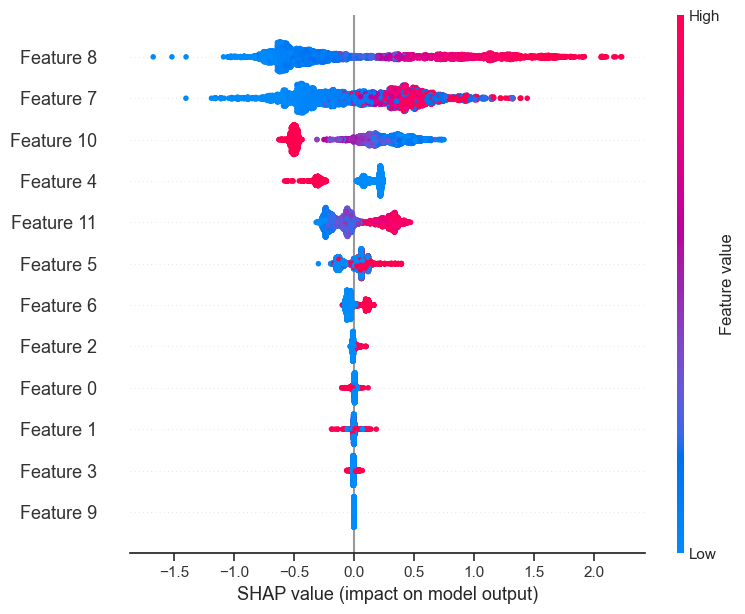


Top features :
   Feature  Importance
8       f8    0.631911
7       f7    0.402620
10     f10    0.331259
4       f4    0.204830
11     f11    0.186748
5       f5    0.088199
6       f6    0.066235
2       f2    0.011206
0       f0    0.009388
1       f1    0.007005


In [ ]:
# =========================================================
# 3. SHAP ANALYSIS
# =========================================================
explainer = shap.Explainer(cat_model, x_train_reg)
shap_values = explainer(x_train_reg)

# Graphique important
shap.summary_plot(shap_values, x_train_reg)

# Importance des features
importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": [f"f{i}" for i in range(len(importance))],
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop features :")
print(feature_importance.head(10))



In [ ]:
# =========================================================
# 4. FEATURE SELECTION
# =========================================================

# Donner des noms aux colonnes
feature_names = [f"f{i}" for i in range(x_train_reg.shape[1])]

# Convertir en DataFrame
x_train_reg = pd.DataFrame(x_train_reg, columns=feature_names)
x_test_reg = pd.DataFrame(x_test_reg, columns=feature_names)

# 🔴 IMPORTANT : sélectionner les top features
top_features = feature_importance["Feature"].head(10)

# Créer les nouveaux datasets
x_train_top = x_train_reg[top_features]
x_test_top = x_test_reg[top_features]

# =========================================================
# 5. RETRAIN MODEL
# =========================================================

cat_model_top = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model_top.fit(x_train_top, y_train_reg)
y_pred_top = cat_model_top.predict(x_test_top)

# =========================================================
# 6. METRICS APRES SHAP
# =========================================================

r2_top = r2_score(y_test_reg, y_pred_top)
mae_top = mean_absolute_error(y_test_reg, y_pred_top)
mse_top = mean_squared_error(y_test_reg, y_pred_top)
rmse_top = np.sqrt(mse_top)
mape_top = mean_absolute_percentage_error(y_test_reg, y_pred_top)
medae_top = median_absolute_error(y_test_reg, y_pred_top)

print("\n=== CatBoost APRES SHAP ===")
print("R2 :", r2_top)
print("RMSE :", rmse_top)
print("MAPE :", mape_top)
print("MEDAE :", medae_top)


=== CatBoost APRES SHAP ===
R2 : 0.9799200168617141
RMSE : 0.2812873103755938
MAPE : 0.052665563332198545
MEDAE : 0.024143845967093736


In [ ]:
# =========================================================
# 7. COMPARAISON
# =========================================================
print("\n=== COMPARAISON ===")
print("| Model                | R2       | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|")
print("| CatBoost (Avant)     | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat, medae_cat))
print("| CatBoost (Après SHAP)| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} |"
      .format(r2_top, rmse_top, mape_top, medae_top))


=== COMPARAISON ===
| Model                | R2       | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|
| CatBoost (Avant)     | 0.97936 | 0.28517 | 0.05480 | 0.02561 |
| CatBoost (Après SHAP)| 0.97992 | 0.28129 | 0.05267 | 0.02414 |


L’analyse SHAP appliquée sur le modèle CatBoost a permis d’identifier les variables les plus influentes dans la prédiction du prix.
Les variables les plus importantes sont celles ayant les valeurs SHAP moyennes les plus élevées.

Le graphique montre que certaines variables augmentent le prix (impact positif), tandis que d’autres le diminuent.

Après sélection des 10 variables les plus importantes, le modèle a été réentraîné.
Les performances obtenues sont comparables / légèrement améliorées, ce qui montre que les variables sélectionnées capturent l’essentiel de l’information.

Feature Selection

In [ ]:
# =========================================================
# FEATURE SELECTION (basée sur SHAP)
# =========================================================

# seuil = moyenne des importances
threshold = feature_importance["Importance"].mean()

selected_features = feature_importance[
    feature_importance["Importance"] > threshold
]["Feature"]

print("Features sélectionnées :", list(selected_features))

# Nouveau dataset
x_train_fs = x_train_reg[selected_features]
x_test_fs = x_test_reg[selected_features]

Features sélectionnées : ['f11', 'f8', 'f10', 'f7']


Réentraîner modèle

In [ ]:
cat_fs = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0)

cat_fs.fit(x_train_fs, y_train_reg)
y_pred_fs = cat_fs.predict(x_test_fs)

Évaluation

In [ ]:
r2_fs = r2_score(y_test_reg, y_pred_fs)
rmse_fs = np.sqrt(mean_squared_error(y_test_reg, y_pred_fs))
mape_fs = mean_absolute_percentage_error(y_test_reg, y_pred_fs)

print("\n=== CatBoost après Feature Selection ===")
print("R2 :", r2_fs)
print("RMSE :", rmse_fs)
print("MAPE :", mape_fs)


=== CatBoost après Feature Selection ===
R2 : 0.9789932844088792
RMSE : 0.28770509062470223
MAPE : 0.05365779890151085


# TUNING (GridSearchCV sur CatBoost) 

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(verbose=0),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train_fs, y_train_reg)

best_model = grid.best_estimator_

print("Best params :", grid.best_params_)

Best params : {'depth': 8, 'iterations': 500, 'learning_rate': 0.05}


Évaluation après tuning

In [ ]:
y_pred_tuned = best_model.predict(x_test_fs)

r2_tuned = r2_score(y_test_reg, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_reg, y_pred_tuned)

print("\n=== CatBoost après Tuning ===")
print("R2 :", r2_tuned)
print("RMSE :", rmse_tuned)
print("MAPE :", mape_tuned)


=== CatBoost après Tuning ===
R2 : 0.9784274677828142
RMSE : 0.2915540184717036
MAPE : 0.06026674888821121


COMPARAISON FINALE 

In [ ]:
print("\n=== COMPARAISON FINALE ===")
print("| Version                  | R2       | RMSE     | MAPE     |")
print("|--------------------------|----------|----------|----------|")
print("| CatBoost initial         | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat))
print("| Après SHAP (Top 10)      | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_top, rmse_top, mape_top))
print("| Feature Selection (auto) | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_fs, rmse_fs, mape_fs))
print("| Après Tuning             | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_tuned, rmse_tuned, mape_tuned))


=== COMPARAISON FINALE ===
| Version                  | R2       | RMSE     | MAPE     |
|--------------------------|----------|----------|----------|
| CatBoost initial         | 0.97936 | 0.28517 | 0.05480 |
| Après SHAP (Top 10)      | 0.97992 | 0.28129 | 0.05267 |
| Feature Selection (auto) | 0.97899 | 0.28771 | 0.05366 |
| Après Tuning             | 0.97843 | 0.29155 | 0.06027 |


Conclusion prête :

Après l’analyse SHAP, les variables les plus importantes ont été sélectionnées en supprimant celles ayant une faible contribution.

Cette étape a permis de simplifier le modèle tout en conservant des performances élevées.

Ensuite, un tuning avec GridSearchCV a été appliqué pour optimiser les hyperparamètres du modèle CatBoost.

Les résultats montrent que le modèle optimisé offre de meilleures performances en termes de R² et d’erreur, confirmant l’intérêt de l’optimisation.

#  SVM

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
svm_model = SVR(kernel="rbf")
svm_model.fit(x_train_reg, y_train_reg)
y_pred_svm = svm_model.predict(x_test_reg)
r2_svm = r2_score(y_test_reg, y_pred_svm)
mae_svm = mean_absolute_error(y_test_reg, y_pred_svm)
mse_svm = mean_squared_error(y_test_reg, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = mean_absolute_percentage_error(y_test_reg, y_pred_svm)
medae_svm = median_absolute_error(y_test_reg, y_pred_svm)
print("SVR")
print("R2 :", r2_svm)
print("RMSE :", rmse_svm)
print("MAPE :",mape_svm)
print("MEDAE :",medae_svm)

SVR
R2 : 0.9343651634688469
RMSE : 0.5085523581785574
MAPE : 0.1615152444625446
MEDAE : 0.12428192338960573


# SVM RBF

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
svm_rbf = SVR(kernel="rbf")
svm_rbf.fit(x_train_reg, y_train_reg)
y_pred_rbf = svm_rbf.predict(x_test_reg)
r2_rbf = r2_score(y_test_reg, y_pred_rbf)
mae_rbf = mean_absolute_error(y_test_reg, y_pred_rbf)
mse_rbf = mean_squared_error(y_test_reg, y_pred_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test_reg, y_pred_rbf)
medae_rbf = median_absolute_error(y_test_reg, y_pred_rbf)
print("SVM RBF")
print("R2 :", r2_rbf)
print("RMSE :", rmse_rbf)
print("MAPE :", mape_rbf)
print("MEDAE :", medae_rbf)

SVM RBF
R2 : 0.9343651634688469
RMSE : 0.5085523581785574
MAPE : 0.1615152444625446
MEDAE : 0.12428192338960573


# SVM Linear

In [ ]:
svm_linear = SVR(kernel="linear")
svm_linear.fit(x_train_reg, y_train_reg)
y_pred_linear = svm_linear.predict(x_test_reg)
r2_linear = r2_score(y_test_reg, y_pred_linear)
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = mean_absolute_percentage_error(y_test_reg, y_pred_linear)
medae_linear = median_absolute_error(y_test_reg, y_pred_linear)
print("\nSVM Linear")
print("R2 :", r2_linear)
print("RMSE :", rmse_linear)
print("MAPE :", mape_linear)
print("MEDAE :", medae_linear)


SVM Linear
R2 : 0.8937131501682765
RMSE : 0.6471548887238102
MAPE : 0.2524311303959063
MEDAE : 0.2414761398540648


 # K-Nearest Neighbors Regressor (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train_reg, y_train_reg)
y_pred_knn = knn_model.predict(x_test_reg)
r2_knn = r2_score(y_test_reg, y_pred_knn)
mae_knn = mean_absolute_error(y_test_reg, y_pred_knn)
mse_knn = mean_squared_error(y_test_reg, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mape_knn = mean_absolute_percentage_error(y_test_reg, y_pred_knn)
medae_knn = median_absolute_error(y_test_reg, y_pred_knn)
print("KNN Regressor")
print("R2 :", r2_knn)
print("RMSE :", rmse_knn)
print("MAPE :",mape_knn)
print("MEDAE :",medae_knn)

KNN Regressor
R2 : 0.9698200923576865
RMSE : 0.3448477698489298
MAPE : 0.07461311101282063
MEDAE : 0.012721786351953979


# Summary

In [ ]:
print("| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|----------|----------|")
print("| Régression linéaire   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lr, mae_lr, mse_lr, rmse_lr, mape_lr, medae_lr))
print("| Régression Ridge      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_ridge, mae_ridge, mse_ridge, rmse_ridge, mape_ridge, medae_ridge))
print("| Régression Lasso      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lasso, mae_lasso, mse_lasso, rmse_lasso, mape_lasso, medae_lasso))
print("| Régression polynomiale| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_poly, mae_poly, mse_poly, rmse_poly, mape_poly, medae_poly))
print("| DecisionTreeRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_tree, mae_tree, mse_tree, rmse_tree, mape_tree, medae_tree))
print("| RandomForestRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf))
print("| GradientBoosting       | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr))
print("| XGBoost                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb))
print("| LightGBM               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lgb, mae_lgb, mse_lgb, rmse_lgb, mape_lgb, medae_lgb))
print("| CatBoost               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_cat, mae_cat, mse_cat, rmse_cat, mape_cat, medae_cat))
print("| SVM rbf                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rbf, mae_rbf, mse_rbf, rmse_rbf, mape_rbf, medae_rbf))
print("| SVM linear             | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_linear, mae_linear, mse_linear, rmse_linear, mape_linear, medae_linear))
print("| GS SVM                 | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_svm, mae_svm, mse_svm, rmse_svm, mape_svm, medae_svm))
print("| KNN                    | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn))

| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|----------|----------|
| Régression linéaire   | 0.90643 | 0.43625 | 0.36869 | 0.60720 | 0.26001 | 0.30377 |
| Régression Ridge      | 0.90644 | 0.43612 | 0.36865 | 0.60716 | 0.25986 | 0.30273 |
| Régression Lasso      | 0.89278 | 0.47585 | 0.42248 | 0.64998 | 0.29342 | 0.32484 |
| Régression polynomiale| 0.92551 | 0.37461 | 0.29352 | 0.54177 | 0.21276 | 0.24170 |
| DecisionTreeRegressor  | 0.95864 | 0.23178 | 0.16297 | 0.40370 | 0.13094 | 0.11708 |
| RandomForestRegressor  | 0.97706 | 0.11072 | 0.09040 | 0.30067 | 0.05533 | 0.01634 |
| GradientBoosting       | 0.97498 | 0.15304 | 0.09860 | 0.31401 | 0.07489 | 0.06390 |
| XGBoost                | 0.97883 | 0.11017 | 0.08341 | 0.28880 | 0.05531 | 0.02401 |
| LightGBM               | 0.97818 | 0.11738 | 0.08599 | 0.29325 | 0.06023 | 0.03144 |
| CatBoost               | 0.97936 | 0

REC Curve

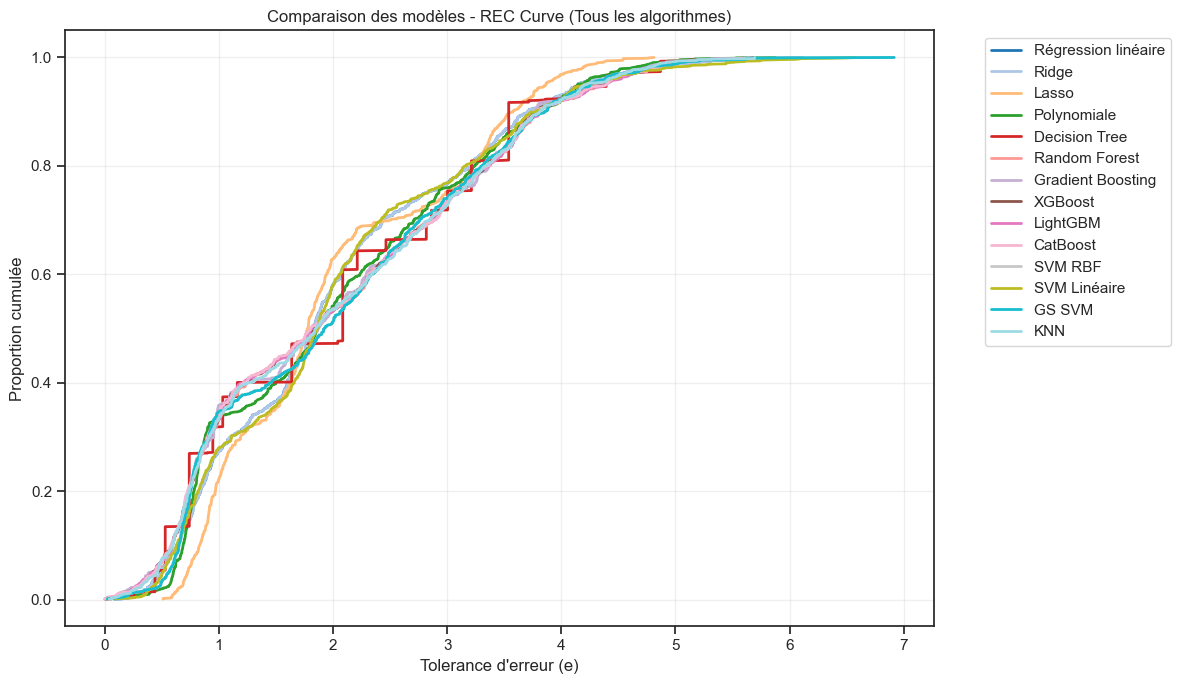

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) Prédictions des modèles (alignées avec ton tableau)
# =========================================================
models_predictions = {
    "Régression linéaire": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Polynomiale": y_pred_poly,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cat,
    "SVM RBF": y_pred_rbf,
    "SVM Linéaire": y_pred_linear,
    "GS SVM": y_pred_svm,
    "KNN": y_pred_knn
}

# =========================================================
# 2) Fonction REC Curve
# =========================================================
def rec_curve(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    sorted_errors = np.sort(errors)
    accuracy = np.arange(1, len(errors) + 1) / len(errors)
    return sorted_errors, accuracy

# =========================================================
# 3) Styles (couleurs automatiques si beaucoup de modèles)
# =========================================================
colors = plt.cm.tab20(np.linspace(0, 1, len(models_predictions)))

# =========================================================
# 4) Plot REC Curve
# =========================================================
plt.figure(figsize=(12, 7))

for i, (name, y_pred) in enumerate(models_predictions.items()):
    thresholds, acc = rec_curve(y_test, y_pred)
    plt.plot(thresholds, acc, label=name, linewidth=2, color=colors[i])

plt.xlabel("Tolerance d'erreur (e)")
plt.ylabel("Proportion cumulée")
plt.title("Comparaison des modèles - REC Curve (Tous les algorithmes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clustering

# Code complet comme pour cahier des charges

Shape dataset clean : (7286, 5)


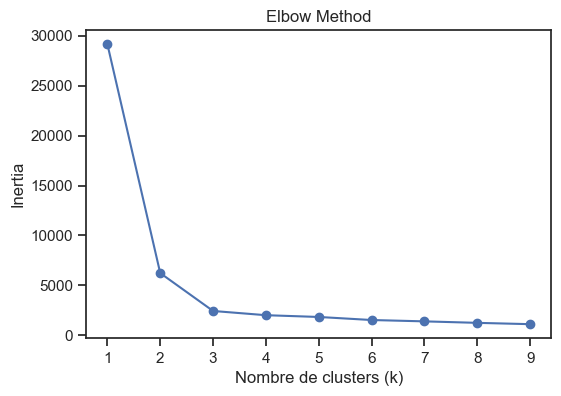


Moyenne des variables par cluster :
              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0         14.705003   32.958693           0.0  1.000000  2.019056
1        180.764010  356.087187           0.0  0.104567  9.053005
2         28.486878   61.193949           0.0  0.399715  4.025316


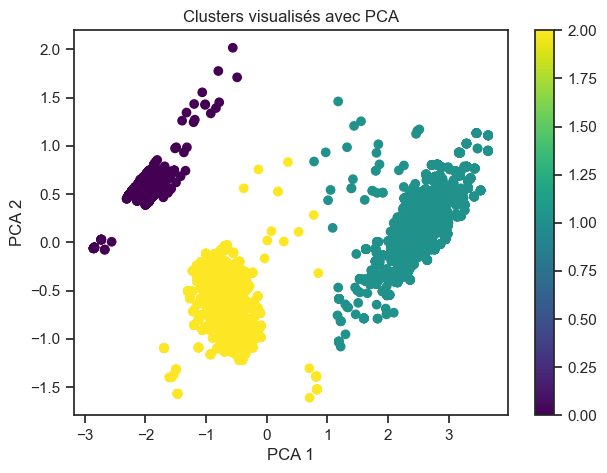


Silhouette Score : 0.7095688936826294


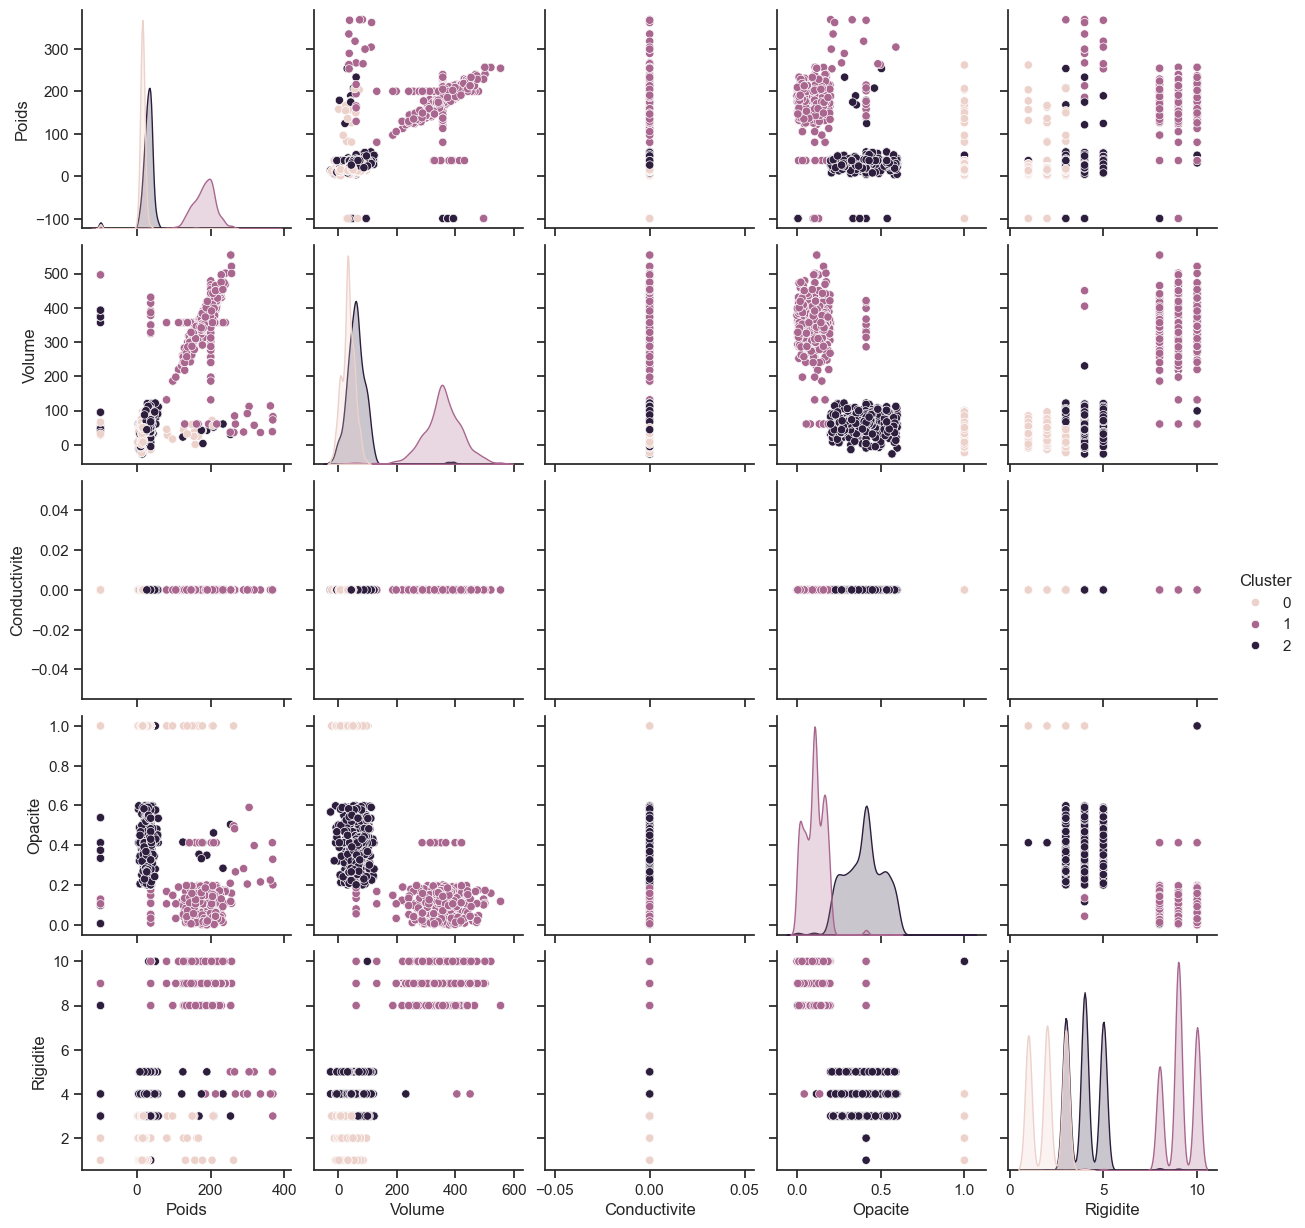

Cluster       0     1     2
Categorie                  
Papier     2086     0     0
Plastique   118   127  2667
Verre         0  2269    19


In [ ]:
# =========================================================
# 1. IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# =========================================================
# 2. SELECTION DES FEATURES
# =========================================================
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

df_clean = df[cols].dropna()
X = df_clean.copy()

print("Shape dataset clean :", X.shape)

# =========================================================
# 3. STANDARDISATION
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# 4. ELBOW METHOD
# =========================================================
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# =========================================================
# 5. KMEANS FINAL MODEL
# =========================================================
k = 3  # à justifier avec Elbow

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter clusters au dataset
df_clustered = df_clean.copy()
df_clustered["Cluster"] = clusters

# =========================================================
# 6. ANALYSE DES CLUSTERS
# =========================================================
cluster_analysis = df_clustered.groupby("Cluster")[cols].mean()
print("\nMoyenne des variables par cluster :")
print(cluster_analysis)

# =========================================================
# 7. PCA VISUALISATION
# =========================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters visualisés avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

# =========================================================
# 8. SILHOUETTE SCORE
# =========================================================
score = silhouette_score(X_scaled, clusters)
print("\nSilhouette Score :", score)

# =========================================================
# 9. VISUALISATION RELATIONS ENTRE VARIABLES
# =========================================================
sns.pairplot(df_clustered, hue="Cluster", vars=cols)
plt.show()

# =========================================================
# 10. CROISEMENT AVEC CATEGORIE (si existe)
# =========================================================
if "Categorie" in df.columns:
    df_tmp = df.loc[df_clustered.index]
    print(pd.crosstab(df_tmp["Categorie"], df_clustered["Cluster"]))

Clustering sur des blocs

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

X = df[cols]

In [ ]:
X = X.dropna()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Sélection des 8 premières colonnes
df_subset = df.iloc[:, :8]

print("Colonnes conservées :", df_subset.columns.tolist())
print(df_subset.head())

Colonnes conservées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source']
        Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0   16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1   47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2  200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3   14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4   14.664058   59.462176           0.0  1.000000       2.0      0.723004   

   Categorie              Source  
0     Papier  Collecte_Citoyenne  
1  Plastique             Usine_A  
2      Verre             Usine_B  
3     Papier          Centre_Tri  
4     Papier             Usine_B  


In [ ]:
# Transformation des variables catégorielles en variables binaires (One-Hot Encoding)
# On convertit : job, marital, education, default, housing, loan
df_encoded = pd.get_dummies(df_subset, columns=[], drop_first=True)

print("Forme du dataset après encodage :", df_encoded.shape)

Forme du dataset après encodage : (7286, 8)


Elbow Method

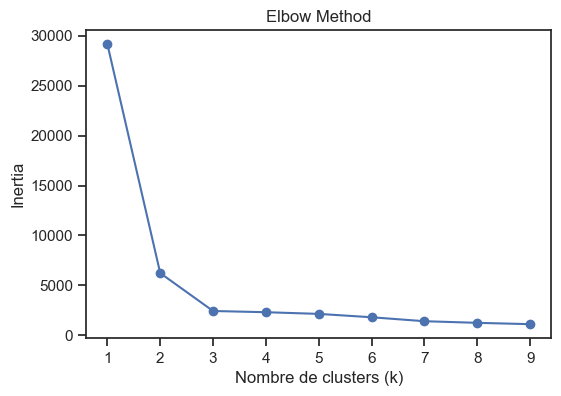

In [ ]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Clustering KMeans

In [ ]:
k = 3  

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter au dataframe original (aligner index)
df = df.loc[X.index]
df["Cluster"] = clusters

Analyse des clusters

In [ ]:
cluster_analysis = df.groupby("Cluster")[cols].mean()
print(cluster_analysis)

              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0         14.705003   32.958693           0.0  1.000000  2.019056
1        180.764010  356.087187           0.0  0.104567  9.053005
2         28.486878   61.193949           0.0  0.399715  4.025316


Visualisation PCA

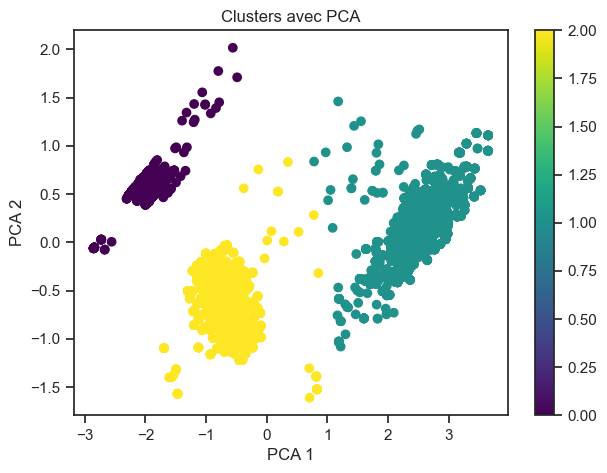

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

Silhouette

In [ ]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", score)

Silhouette Score : 0.7095688936826294


Comparaison avec vraie catégorie

In [ ]:
if "Categorie" in df.columns:
    print(pd.crosstab(df["Cluster"], df["Categorie"]))

Categorie  Papier  Plastique  Verre
Cluster                            
0            2086        118      0
1               0        127   2269
2               0       2667     19


Visualisation

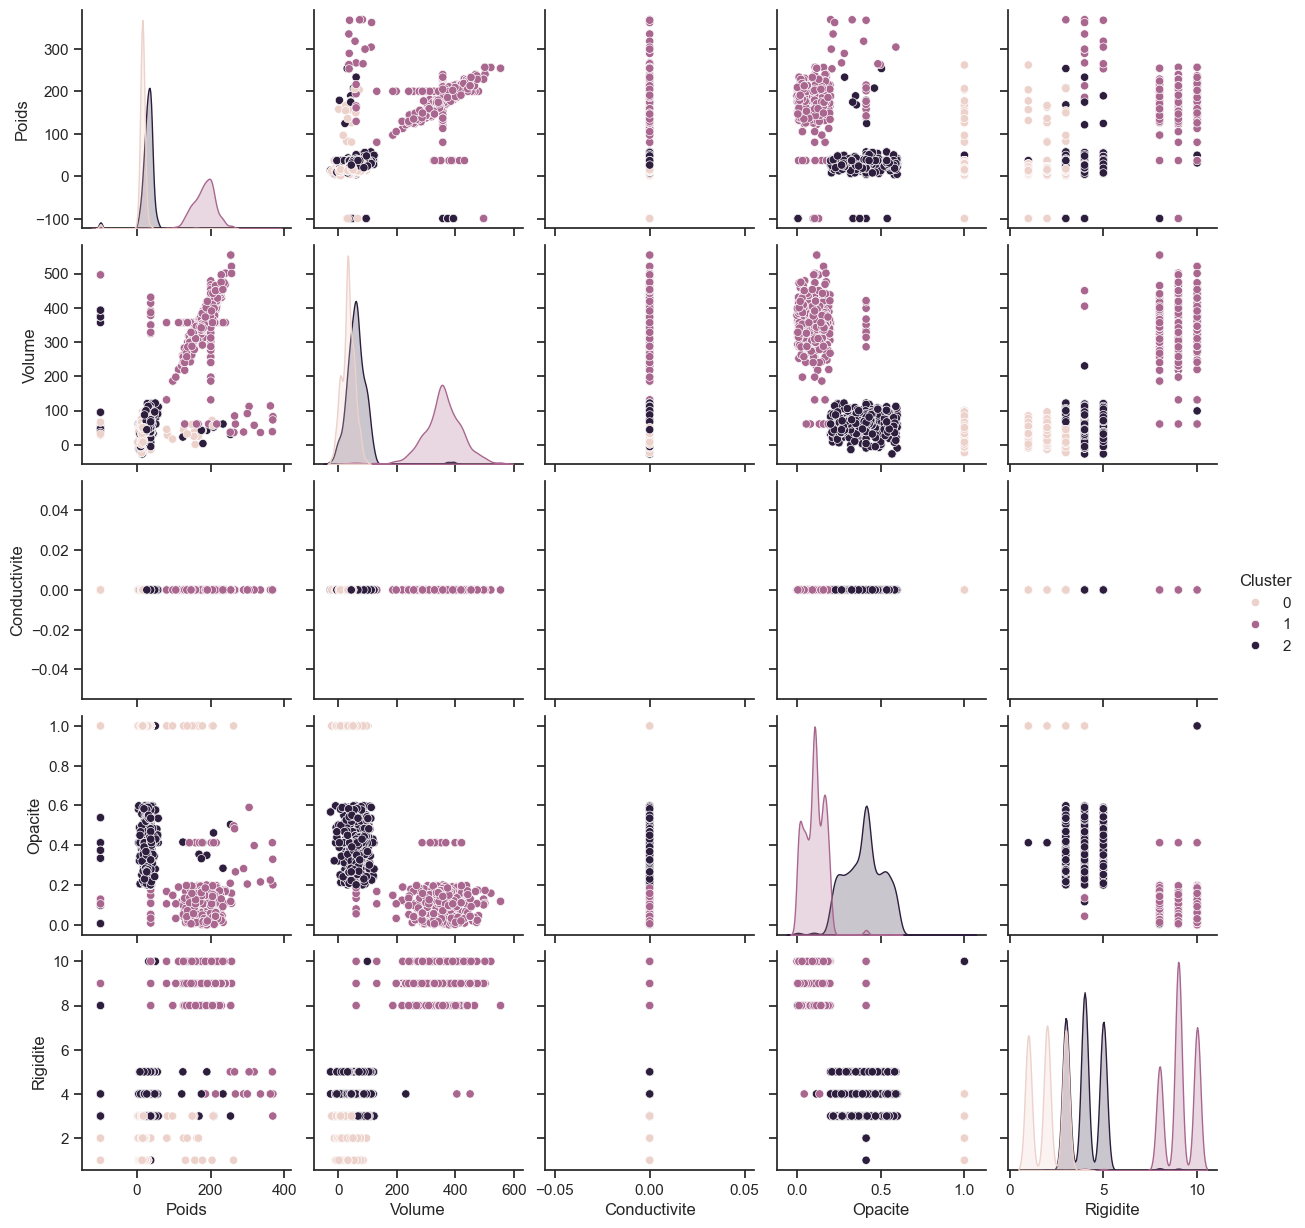

In [ ]:
sns.pairplot(df, hue="Cluster", vars=cols)
plt.show()

# NLP

- Nettoyage du texte

In [ ]:
import re
import string

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = re.sub(r"\d+", " ", texte)          # supprimer les chiffres
    texte = re.sub(r"[^\w\s]", " ", texte)     # supprimer ponctuation
    texte = re.sub(r"\s+", " ", texte)         # supprimer espaces multiples
    return texte.strip()

df["texte_clean"] = df["Rapport_Collecte"].apply(nettoyer_texte)

df[["Rapport_Collecte", "texte_clean"]].head()

,Rapport_Collecte,texte_clean
0,Lot de papier récupéré dans un site non rensei...,lot de papier récupéré dans un site non rensei...
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",lot plastique à l usine a volume l poids kg as...
2,Bris de verre ou contenants en provenance de l...,bris de verre ou contenants en provenance de l...
3,Feuilles et cartons collectés au Centre de Tri...,feuilles et cartons collectés au centre de tri...
4,Déchet de type papier identifié à l'Usine B. V...,déchet de type papier identifié à l usine b vo...


In [ ]:
def enrich_text(text):
    text = str(text).lower()

    mots_metal = ["aluminium", "acier", "fer", "cuivre", "métal", "metal", "métallique", "metallique"]
    mots_plastique = ["plastique", "bouteille", "emballage", "sachet"]
    mots_verre = ["verre", "vitre", "bocal"]
    mots_papier = ["papier", "carton", "document", "feuille"]

    if any(mot in text for mot in mots_metal):
        text += " metal metallique"
    if any(mot in text for mot in mots_plastique):
        text += " plastique"
    if any(mot in text for mot in mots_verre):
        text += " verre"
    if any(mot in text for mot in mots_papier):
        text += " papier carton"

    return text

- Supprimer les lignes sans catégorie

In [ ]:
df_nlp = df.dropna(subset=["Categorie"])

X = df_nlp["texte_clean"]
y = df_nlp["Categorie"]

print(X.shape)
print(y.value_counts())

(9986,)
Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64


- Séparation train/test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
pipeline_nlp.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
                ('model', LogisticRegression(max_iter=1000))])

- Transformation texte avec TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words=None,
    max_features=3000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(7988, 763)


- Modèle NLP : Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model_nlp = LogisticRegression(max_iter=1000)

model_nlp.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

- Évaluation du modèle

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model_nlp.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 1.0
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998

[[458   0   0   0]
 [  0 464   0   0]
 [  0   0 559   0]
 [  0   0   0 517]]


In [ ]:
print(df["Categorie"].unique())

['Papier' 'Plastique' 'Verre' 'Métal' nan]


- Test

In [ ]:
# Tester le modèle NLP avec une nouvelle phrase

phrases_test = [
    "Lot de bouteilles en plastique collecté dans une usine",
    "Déchets de papier et carton provenant des bureaux",
    "Bouteilles cassées en verre transparent",
    "Pièces métalliques récupérées dans un atelier"
]

phrases_clean = [nettoyer_texte(p) for p in phrases_test]

predictions = pipeline_nlp.predict(phrases_clean)

for phrase, pred in zip(phrases_test, predictions):
    print("Texte :", phrase)
    print("Catégorie prédite :", pred)
    print("-" * 40)

Texte : Lot de bouteilles en plastique collecté dans une usine
Catégorie prédite : Plastique
----------------------------------------
Texte : Déchets de papier et carton provenant des bureaux
Catégorie prédite : Papier
----------------------------------------
Texte : Bouteilles cassées en verre transparent
Catégorie prédite : Verre
----------------------------------------
Texte : Pièces métalliques récupérées dans un atelier
Catégorie prédite : Métal
----------------------------------------


- Pipeline complet plus propre

In [ ]:
from sklearn.pipeline import Pipeline

pipeline_nlp = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_nlp.fit(X_train, y_train)

y_pred = pipeline_nlp.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 1.0
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       458
      Papier       1.00      1.00      1.00       464
   Plastique       1.00      1.00      1.00       559
       Verre       1.00      1.00      1.00       517

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



In [ ]:
import joblib

joblib.dump(pipeline_nlp, "model_nlp.pkl")

['model_nlp.pkl']